In [ ]:
# %% [markdown]
"""
# Unsupervised Oil Spill Detection on HOSD (GMxx) with Isolation Forest

Pipeline based on:
"Hyperspectral Remote Sensing Benchmark Database for Oil Spill Detection
with an Isolation Forest-Guided Unsupervised Detector" (Duan et al., 2022).

Steps:
1. Load hyperspectral cube.
2. Estimate noise variance per band and remove heavily noisy bands.
3. Reduce dimensionality with (Kernel) PCA.
4. Run Isolation Forest on reduced data to get anomaly scores.
5. Cluster scores (k-means) → pseudo labels (oil vs water).
6. Train RBF-SVM using 1% of pseudo labels.
7. Predict oil probability map for all pixels.
8. Refine with Random Walker (approximation of ERW).
"""


'\n# Unsupervised Oil Spill Detection on HOSD (GMxx) with Isolation Forest\n\nPipeline based on:\n"Hyperspectral Remote Sensing Benchmark Database for Oil Spill Detection\nwith an Isolation Forest-Guided Unsupervised Detector" (Duan et al., 2022).\n\nSteps:\n1. Load hyperspectral cube.\n2. Estimate noise variance per band and remove heavily noisy bands.\n3. Reduce dimensionality with (Kernel) PCA.\n4. Run Isolation Forest on reduced data to get anomaly scores.\n5. Cluster scores (k-means) → pseudo labels (oil vs water).\n6. Train RBF-SVM using 1% of pseudo labels.\n7. Predict oil probability map for all pixels.\n8. Refine with Random Walker (approximation of ERW).\n'

In [ ]:
# %%  Install (run once in your environment)
# If you're in a fresh env, uncomment this cell and run once.

# !pip install numpy scipy scikit-learn scikit-image matplotlib


In [ ]:
# %%  Imports & config

import numpy as np
import scipy.io as sio
from scipy.ndimage import convolve
from sklearn.decomposition import PCA, KernelPCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from skimage.segmentation import random_walker
import matplotlib.pyplot as plt


In [ ]:
# %%  Hyperparameters (you can tweak these)

# --- Band selection ---
NOISE_THRESHOLD_FACTOR = 1.0  # same structure as paper's Eq. (3)

# --- Dimensionality reduction ---
USE_KERNEL_PCA = False        # True = KPCA (slower), False = linear PCA
KPCA_COMPONENTS = 25          # D in the paper
KPCA_GAMMA = None             # None → sklearn default 1/n_features

# --- Isolation Forest ---
IFOREST_TREES = 800           # T in the paper
IFOREST_MAX_SAMPLES = 256     # fraction of pixels used per tree (to save memory)
IFOREST_RANDOM_STATE = 0

# --- k-means for pseudo labels ---
N_CLUSTERS = 2                # oil vs water

# --- SVM ---
TRAIN_FRACTION = 0.01         # ~1% pseudo labels
SVM_C = 10.0
SVM_GAMMA = 'scale'
SVM_RANDOM_STATE = 0

# --- Random Walker (ERW-like step) ---
RW_BETA = 710.0               # inspired by paper's β (they used 710)
RW_TOL = 1e-3
RW_MODE = 'cg_mg'             # fast solver


In [ ]:
# %%  Utility: load HOSD scene (GMxx.mat)

def load_hosd_scene(mat_path, img_key="img", map_key="map"):
    """
    Loads a HOSD .mat file.
    Assumes:
      - img: H x W x B (hyperspectral cube)
      - map: H x W (0 = water, 1 = oil), optional
    """
    mat = sio.loadmat(mat_path)
    cube = mat[img_key]  # int16 in HOSD
    cube = cube.astype(np.float32)
    gt = None
    if map_key in mat:
        gt = mat[map_key]
    return cube, gt


In [ ]:
# %%  Step 1: Noise variance estimation & band selection

def estimate_noise_variance_per_band(cube):
    """
    Implements Eq. (1) from the paper:
    sigma_n = sqrt(pi/2) / (6*(W-2)*(H-2)) * sum |In * M|
    where M is the Laplacian mask.
    """
    H, W, B = cube.shape
    laplacian_mask = np.array([[1, -2, 1],
                               [-2, 4, -2],
                               [1, -2, 1]], dtype=np.float32)

    sigmas = np.zeros(B, dtype=np.float32)

    norm_factor = np.sqrt(np.pi / 2.0) / (6.0 * (W - 2) * (H - 2))

    for b in range(B):
        band = cube[:, :, b]
        conv = convolve(band, laplacian_mask, mode='nearest')
        sigmas[b] = norm_factor * np.sum(np.abs(conv))

    return sigmas


def select_bands_by_noise(cube, sigmas, threshold_factor=NOISE_THRESHOLD_FACTOR):
    """
    Eq. (3) from the paper:
       keep bands where sigma_n < (1/(2*IN)) * sum(sigma)
    threshold_factor allows minor tuning; paper uses 1/2.
    """
    B = cube.shape[2]
    threshold = threshold_factor * np.sum(sigmas) / B
    keep_mask = sigmas < threshold
    selected_cube = cube[:, :, keep_mask]
    return selected_cube, keep_mask, threshold


In [ ]:
import numpy
import scipy
import sklearn
import skimage
import matplotlib

print(f"NumPy version: {numpy.__version__}")
print(f"SciPy version: {scipy.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Scikit-image version: {skimage.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")

NumPy version: 2.0.2
SciPy version: 1.16.3
Scikit-learn version: 1.6.1
Scikit-image version: 0.25.2
Matplotlib version: 3.10.0


Please compare these versions with those mentioned in the paper, or try installing `pyamg` if it's missing, as suggested by the `random_walker` warning. If you'd like to try installing `pyamg`, let me know.

In [ ]:
# %%  Step 2: (Kernel) PCA dimensionality reduction

def reduce_dimensionality(cube_sel, use_kernel=USE_KERNEL_PCA,
                          n_components=KPCA_COMPONENTS, kpca_gamma=KPCA_GAMMA):
    """
    Flattens cube, applies PCA or KernelPCA, then reshapes back.
    """
    H, W, B = cube_sel.shape
    X = cube_sel.reshape(-1, B)  # (N_pixels, B)

    if use_kernel:
        # WARNING: KernelPCA is O(N^2). For big images you might want to
        # subsample X for fitting. Here we assume enough RAM.
        kpca = KernelPCA(
            n_components=n_components,
            kernel="rbf",
            gamma=kpca_gamma,
            fit_inverse_transform=False,
            n_jobs=-1,
            random_state=0
        )
        X_red = kpca.fit_transform(X)
        model = kpca
    else:
        pca = PCA(
            n_components=n_components,
            whiten=False,
            random_state=0
        )
        X_red = pca.fit_transform(X)
        model = pca

    Y = X_red.reshape(H, W, -1)   # (H, W, D)
    return Y, model


In [ ]:
# %%  Step 3: Isolation Forest → probability map

def isolation_forest_scores(Y):
    """
    Run Isolation Forest on dimensionality-reduced data.
    We use sklearn's score_samples as anomaly score, then rescale to [0,1].
    Higher value = more anomalous (likely oil).
    """
    H, W, D = Y.shape
    X = Y.reshape(-1, D)

    iso = IsolationForest(
        n_estimators=IFOREST_TREES,
        max_samples=IFOREST_MAX_SAMPLES,
        contamination=0.005,
        random_state=IFOREST_RANDOM_STATE,
        n_jobs=-1
    )
    iso.fit(X)

    # sklearn: higher score_samples = less abnormal
    raw_scores = -iso.score_samples(X)  # invert so higher = more abnormal
    raw_scores = raw_scores.reshape(H, W)

    scaler = MinMaxScaler()
    p = scaler.fit_transform(raw_scores.reshape(-1, 1)).reshape(H, W)

    return p, iso


In [ ]:
# %%  Step 4: k-means clustering on probability map → pseudo labels

def kmeans_pseudo_labels(prob_map, n_clusters=N_CLUSTERS):
    """
    Cluster pixels by their 1D probability value.
    The cluster with higher mean probability is labeled as oil (1),
    the other as water (0).
    """
    H, W = prob_map.shape
    Xp = prob_map.reshape(-1, 1)

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=0,
        n_init="auto"
    )
    labels = kmeans.fit_predict(Xp)

    # Identify oil cluster as the one with higher mean probability
    means = []
    for c in range(n_clusters):
        means.append(Xp[labels == c].mean())
    means = np.array(means)
    oil_cluster = np.argmax(means)

    pseudo_labels = (labels == oil_cluster).astype(np.uint8).reshape(H, W)
    return pseudo_labels, kmeans


In [ ]:
# %%  Step 5: Sample ~1% pseudo labels and train SVM

def sample_training_from_pseudo(pseudo_labels, frac=TRAIN_FRACTION,
                                random_state=SVM_RANDOM_STATE):
    """
    Returns indices of sampled training pixels and their labels.
    """
    H, W = pseudo_labels.shape
    N = H * W
    flat_labels = pseudo_labels.reshape(-1)

    oil_idx = np.where(flat_labels == 1)[0]
    water_idx = np.where(flat_labels == 0)[0]

    # Per-class 1% sampling (at least 1 sample)
    n_oil = max(1, int(len(oil_idx) * frac))
    n_water = max(1, int(len(water_idx) * frac))

    rng = np.random.default_rng(random_state)
    oil_train = rng.choice(oil_idx, size=n_oil, replace=False)
    water_train = rng.choice(water_idx, size=n_water, replace=False)

    train_idx = np.concatenate([oil_train, water_train])
    train_labels = flat_labels[train_idx]

    return train_idx, train_labels


def train_svm_on_reduced(Y, train_idx, train_labels):
    """
    Train RBF SVM on dimensionality-reduced data at selected indices.
    """
    H, W, D = Y.shape
    X = Y.reshape(-1, D)

    svm = SVC(
        kernel='rbf',
        C=SVM_C,
        gamma=SVM_GAMMA,
        probability=True,
        random_state=SVM_RANDOM_STATE
    )
    svm.fit(X[train_idx], train_labels)

    # Predict probability for all pixels (probability of class 1 = oil)
    prob_all = svm.predict_proba(X)[:, 1].reshape(H, W)

    scaler = MinMaxScaler()
    prob_all = scaler.fit_transform(prob_all.reshape(-1, 1)).reshape(H, W)

    return prob_all, svm


In [ ]:
# %%  Step 6: Random Walker spatial refinement (ERW-like)

def random_walker_refinement(base_image, prob_map,
                             high_thr=0.9, low_thr=0.1):
    """
    Approximate the ERW step using scikit-image's random_walker.

    - base_image: a 2D image for graph weights (we use first PC).
    - prob_map: SVM oil probability map.
    - high_thr / low_thr: thresholds to create confident seeds.
    """
    H, W = prob_map.shape

    # Seeds: 1 = oil, 2 = water, 0 = unknown
    markers = np.zeros((H, W), dtype=np.int32)
    markers[prob_map >= high_thr] = 1
    markers[prob_map <= low_thr] = 2

    # If there are too few seeds, relax thresholds
    if np.sum(markers == 1) < 10 or np.sum(markers == 2) < 10:
        markers[:] = 0
        markers[prob_map >= 0.7] = 1
        markers[prob_map <= 0.3] = 2

    labels_rw = random_walker(
        base_image,
        markers,
        beta=RW_BETA,
        mode=RW_MODE,
        tol=RW_TOL
    )

    # Map RW labels → {0,1} (oil=1, water=0)
    refined = (labels_rw == 1).astype(np.float32)

    return refined, labels_rw


In [ ]:
# %%  High-level pipeline function

def run_full_pipeline(mat_path, img_key="img", map_key="map",
                      visualize=True):
    # 1. Load
    cube, gt = load_hosd_scene(mat_path, img_key, map_key)
    H, W, B = cube.shape
    print(f"Loaded cube {cube.shape}, dtype={cube.dtype}")

    # Quick per-band normalization (optional, stabilizes noise estimation)
    cube_norm = cube.copy()
    for b in range(B):
        band = cube_norm[:, :, b]
        mn, mx = np.min(band), np.max(band)
        if mx > mn:
            cube_norm[:, :, b] = (band - mn) / (mx - mn)

    # 2. Noise variance & band selection
    sigmas = estimate_noise_variance_per_band(cube_norm)
    cube_sel, keep_mask, thr = select_bands_by_noise(cube_norm, sigmas)
    print(f"Selected {cube_sel.shape[2]} / {B} bands (threshold={thr:.4e})")

    # 3. (K)PCA
    Y, dr_model = reduce_dimensionality(cube_sel)
    print(f"Reduced to {Y.shape[2]} components")

    # 4. Isolation Forest probabilities
    p_iforest, iso_model = isolation_forest_scores(Y)
    print("Isolation Forest done.")

    # 5. k-means pseudo labels
    pseudo_labels, km_model = kmeans_pseudo_labels(p_iforest)
    print("k-means clustering done.")

    # 6. SVM on 1% pseudo labels
    train_idx, train_labels = sample_training_from_pseudo(pseudo_labels)
    prob_svm, svm_model = train_svm_on_reduced(Y, train_idx, train_labels)
    print("SVM training & prediction done.")

    # 7. Random Walker refinement
    base_img = Y[:, :, 0]  # use first component as intensity
    rw_refined, rw_labels = random_walker_refinement(base_img, prob_svm)
    print("Random Walker refinement done.")

    if visualize:
        # crude RGB using three mid-visible bands (if exist)
        b_ids = np.linspace(0, cube_sel.shape[2]-1, 3, dtype=int)
        rgb = np.stack([cube_sel[:, :, i] for i in b_ids], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

        fig, axs = plt.subplots(2, 3, figsize=(14, 8))
        axs = axs.ravel()

        axs[0].imshow(rgb)
        axs[0].set_title("Pseudo RGB (selected bands)")
        axs[0].axis("off")

        axs[1].imshow(p_iforest, cmap="viridis")
        axs[1].set_title("Isolation Forest probability")
        axs[1].axis("off")

        axs[2].imshow(pseudo_labels, cmap="gray")
        axs[2].set_title("Pseudo labels (0=water,1=oil)")
        axs[2].axis("off")

        axs[3].imshow(prob_svm, cmap="viridis")
        axs[3].set_title("SVM oil probability")
        axs[3].axis("off")

        axs[4].imshow(rw_refined, cmap="gray")
        axs[4].set_title("Random Walker refined mask")
        axs[4].axis("off")

        if gt is not None:
            axs[5].imshow(gt, cmap="gray")
            axs[5].set_title("Ground truth map")
            axs[5].axis("off")
        else:
            axs[5].axis("off")

        plt.tight_layout()
        plt.show()

    results = {
        "cube": cube,
        "cube_selected": cube_sel,
        "noise_sigma": sigmas,
        "keep_mask": keep_mask,
        "Y": Y,
        "p_iforest": p_iforest,
        "pseudo_labels": pseudo_labels,
        "prob_svm": prob_svm,
        "rw_mask": rw_refined,
        "rw_labels": rw_labels,
        "gt": gt,
    }
    return results


Loaded cube (1175, 563, 224), dtype=float32
Selected 185 / 224 bands (threshold=9.8472e-03)
Reduced to 25 components
Isolation Forest done.
k-means clustering done.
SVM training & prediction done.


/usr/local/lib/python3.12/dist-packages/skimage/segmentation/random_walker_segmentation.py:566: UserWarning: "cg_mg" not available, it requires pyamg to be installed. The "cg_j" mode will be used instead.
  X = _solve_linear_system(lap_sparse, B, tol, mode)
/usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py:445: UserWarning: The probability range is outside [0, 1] given the tolerance `prob_tol`. Consider decreasing `beta` and/or decreasing `tol`.
  return func(*args, **kwargs)


Random Walker refinement done.


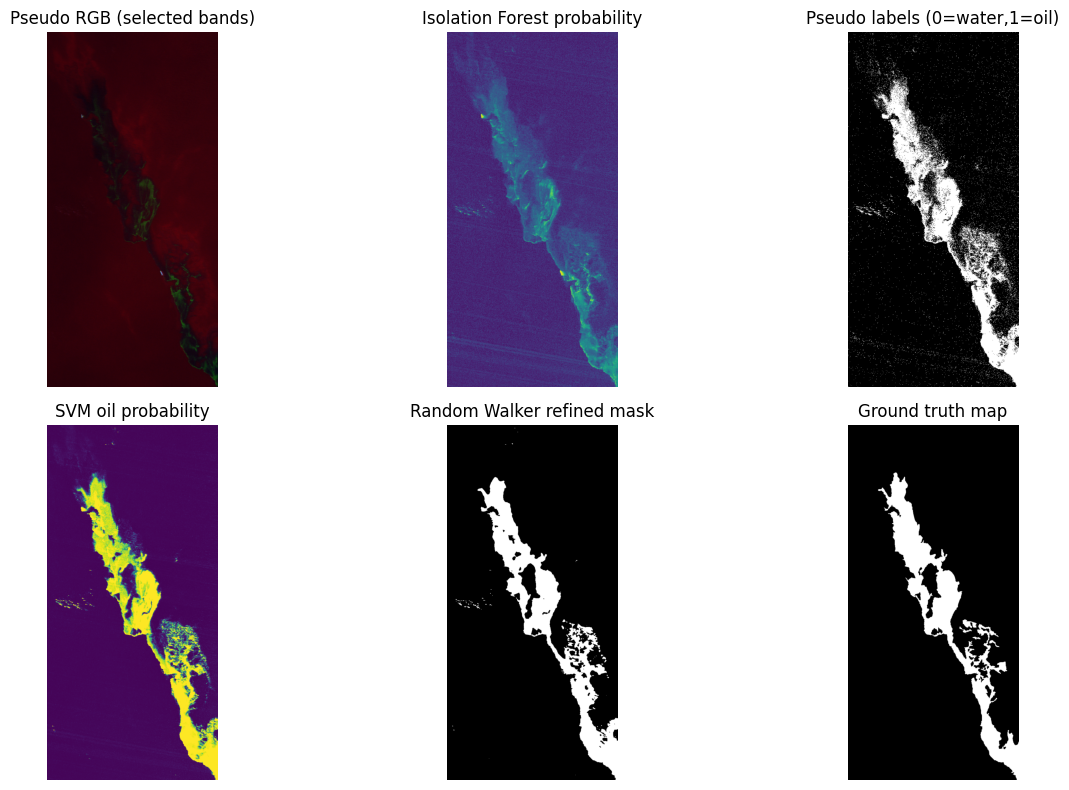

{'cube': array([[[560., 661., 742., ...,   0.,  -2.,   0.],
         [569., 682., 737., ...,   0.,   0.,  -2.],
         [570., 683., 733., ...,   0.,   1.,   2.],
         ...,
         [592., 689., 764., ...,  -1.,   2.,   0.],
         [592., 696., 760., ...,  -1.,   0.,   0.],
         [573., 715., 761., ...,  -1.,  -3.,   0.]],
 
        [[551., 683., 726., ...,   0.,   3.,  -1.],
         [577., 669., 747., ...,  -1.,   0.,   0.],
         [560., 667., 759., ...,  -1.,  -3.,  -4.],
         ...,
         [581., 699., 764., ...,   0.,  -2.,   0.],
         [579., 701., 762., ...,  -1.,  -1.,   0.],
         [579., 683., 740., ...,   0.,  -1.,   0.]],
 
        [[543., 669., 729., ...,   2.,  -1.,   0.],
         [557., 671., 747., ...,   0.,   0.,  -1.],
         [550., 683., 748., ...,  -2.,   0.,   0.],
         ...,
         [592., 671., 746., ...,   1.,   0.,   3.],
         [577., 701., 755., ...,   1.,  -4.,   1.],
         [599., 694., 770., ...,   0.,   1.,  -1.]],
 
     

In [ ]:
# %%  Run the pipeline on one scene (example: GM04.mat)

# Change the path below to wherever your GM04.mat is.
mat_file_path = "GM18.mat"   # e.g. "./GM04.mat" or full path

results = run_full_pipeline(mat_file_path)
results

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

gt = results["gt"].reshape(-1)
pred = results["rw_mask"].reshape(-1)
prob = results["prob_svm"].reshape(-1)

print("Accuracy:", accuracy_score(gt, pred))
print("Precision:", precision_score(gt, pred))
print("Recall:", recall_score(gt, pred))
print("F1-score:", f1_score(gt, pred))
print("AUC:", roc_auc_score(gt, prob))


Accuracy: 0.973157477041684
Precision: 0.8515032417953788
Recall: 0.9202819149655723
F1-score: 0.8845576236696854
AUC: 0.9910273073658294


In [ ]:
# Fill these lists with your computed AUCs for each GM1 ... GM18 scene
auc_original = [0.9472,0.9523,0.9428,0.9655,0.9185,0.8632,0.8452,0.8956,0.9022,0.9303,0.9352,0.9416,0.8785,0.9094,0.8894,0.7563,0.9469]   # AUC values from your reproduced original pipeline
auc_proposed = [0.9740,0.9833,0.9776,0.9895,0.9548,0.9528,0.9096,0.9780,0.9539,0.9826,0.9760,0.9707,0.9218,0.9480,0.9582,0.9266,0.9910]   # AUC values from your MNF + AE pipeline


In [ ]:
len(auc_original)  # should be 18
len(auc_proposed)  # should be 18


17

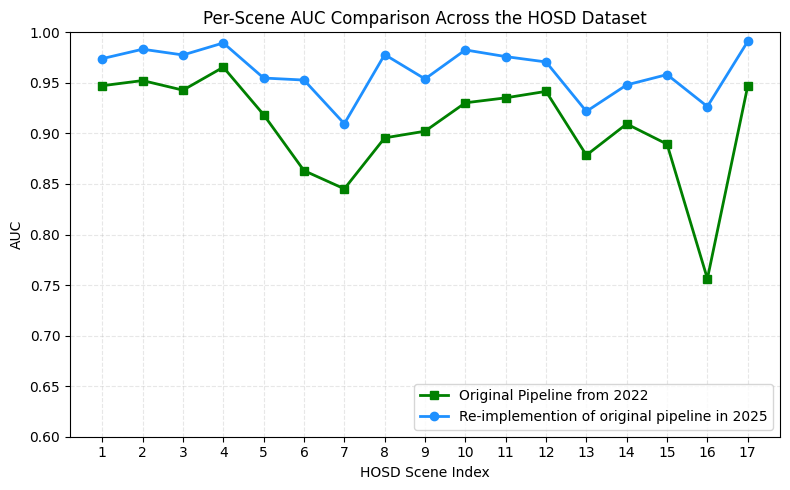

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_scene_auc(auc_orig, auc_prop):
    scenes = np.arange(1, len(auc_orig) + 1)

    plt.figure(figsize=(8, 5))

    # Plot original pipeline
    plt.plot(scenes, auc_orig,
             marker='s', linestyle='-', linewidth=2, markersize=6,
             color='green', label='Original Pipeline from 2022')

    # Plot AE + MNF pipeline
    plt.plot(scenes, auc_prop,
             marker='o', linestyle='-', linewidth=2, markersize=6,
             color='dodgerblue', label='Re-implemention of original pipeline in 2025')

    # Axis labels
    plt.xlabel("HOSD Scene Index")
    plt.ylabel("AUC")

    # Y-limits similar to the example
    plt.ylim(0.6, 1.0)

    # Tick marks exactly like the example
    plt.xticks(scenes)

    # Legend
    plt.legend(loc="lower right")

    # Grid for IEEE readability
    plt.grid(alpha=0.3, linestyle="--")

    # Title
    plt.title("Per-Scene AUC Comparison Across the HOSD Dataset")

    plt.tight_layout()
    plt.show()

# Example usage:
plot_scene_auc(auc_original, auc_proposed)
